# INM707 Deep Reinforcement Learning Coursework  
## Notebook 3: PPO on CartPole-v1

This notebook covers Tasks 9–10 of the coursework. I implement Proximal Policy Optimisation (PPO), apply it to the `CartPole-v1` environment, and analyse the results quantitatively and qualitatively. PPO is used as a second deep reinforcement learning algorithm to contrast with the value-based DQN methods implemented in Notebook 2.

# Task 9: Applying Another Deep Reinforcement Learning Algorithm

For the second advanced reinforcement learning algorithm, I use Proximal Policy Optimisation (PPO). Unlike DQN, which learns an action-value function and selects actions indirectly through Q-values, PPO directly learns a stochastic policy. PPO is an actor-critic method: the actor outputs an action distribution, while the critic estimates the state value.

I use the same `CartPole-v1` environment as in the DQN notebook. This makes the comparison easier because both DQN and PPO are applied to the same continuous-observation, discrete-action control problem.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ImportError as exc:
    raise ImportError(
        "Gymnasium is not installed. Install it with: pip install gymnasium"
    ) from exc

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.distributions import Categorical
except ImportError as exc:
    raise ImportError(
        "PyTorch is not installed. Install it from https://pytorch.org/get-started/locally/"
    ) from exc

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Save results outside the notebook folder
RESULTS_DIR = Path("../Results/ppo")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device: {device}")
print(f"Results will be saved to: {RESULTS_DIR.resolve()}")

Using device: cuda
Results will be saved to: F:\data sci\INM707-DRL-Coursework\Results\ppo


This cell imports the libraries used for the PPO experiment, fixes the random seed for reproducibility, selects GPU acceleration if available, and creates a results directory for this notebook.

In [ ]:
import importlib

try:
    torch._utils
except AttributeError:
    torch._utils = importlib.import_module("torch._utils")

This compatibility cell avoids local PyTorch namespace issues observed on this machine. It does not change the PPO algorithm; it only ensures that PyTorch utilities are accessible during optimisation and tensor handling.

## 9.1 Environment Definition

`CartPole-v1` has a continuous four-dimensional observation space and a discrete two-action space. The objective is to balance the pole for as long as possible. Each time step gives a reward of 1, so a higher episode return means the agent balanced the pole for more time steps.

The maximum return in `CartPole-v1` is 500, and the standard solved threshold is treated as an average return of 475.

In [4]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"Environment: CartPole-v1")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"State dimension: {state_dim}")
print(f"Number of actions: {action_dim}")
print(f"Initial observation: {obs}")

env.close()

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
State dimension: 4
Number of actions: 2
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


The observation space is continuous, so PPO uses neural networks rather than a table. The actor network maps observations to action probabilities, and the critic network maps observations to estimated state values.

## 9.2 PPO Hyperparameter Configuration

I define the PPO hyperparameters in one configuration object. PPO collects trajectories using the current policy, computes discounted returns and advantages, and then performs several optimisation epochs using the clipped surrogate objective.

In [5]:
@dataclass
class PPOConfig:
    env_name: str = "CartPole-v1"
    total_updates: int = 300
    rollout_steps: int = 1024
    max_episode_steps: int = 500

    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_epsilon: float = 0.2

    learning_rate: float = 3e-4
    update_epochs: int = 6
    minibatch_size: int = 256

    entropy_coef: float = 0.01
    value_coef: float = 0.5
    max_grad_norm: float = 0.5

    hidden_dim: int = 128

    eval_every: int = 10
    eval_episodes: int = 10
    solved_threshold: float = 475.0
    rolling_window: int = 20


ppo_config = PPOConfig()
ppo_config

PPOConfig(env_name='CartPole-v1', total_updates=300, rollout_steps=1024, max_episode_steps=500, gamma=0.99, gae_lambda=0.95, clip_epsilon=0.2, learning_rate=0.0003, update_epochs=6, minibatch_size=256, entropy_coef=0.01, value_coef=0.5, max_grad_norm=0.5, hidden_dim=128, eval_every=10, eval_episodes=10, solved_threshold=475.0, rolling_window=20)

The configuration uses a rollout-based PPO setup. The rollout length controls how much on-policy data is collected before each update. The clipping parameter limits how far the policy is allowed to move during optimisation, which is the main stabilising idea in PPO.

## 9.3 Actor-Critic Network

PPO uses an actor-critic architecture. The actor outputs a probability distribution over actions, while the critic estimates the value of the current state. The actor is used to choose actions and compute policy gradients, while the critic reduces variance by estimating expected return.

In [6]:
class ActorCritic(nn.Module):
    """
    Actor-critic network for PPO with a discrete action space.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, states: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        features = self.shared(states)
        action_logits = self.actor(features)
        state_values = self.critic(features)
        return action_logits, state_values

    def get_action_and_value(
        self,
        states: torch.Tensor,
        actions: torch.Tensor = None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Return sampled/evaluated action, log probability, entropy and value.
        """
        logits, values = self.forward(states)
        distribution = Categorical(logits=logits)

        if actions is None:
            actions = distribution.sample()

        log_probs = distribution.log_prob(actions)
        entropy = distribution.entropy()

        return actions, log_probs, entropy, values.squeeze(-1)

The network has shared hidden layers followed by separate actor and critic heads. The actor head produces action logits for a categorical distribution, and the critic head produces a scalar value estimate for the input state.

## 9.4 Rollout Buffer

PPO is an on-policy algorithm, so it collects a batch of fresh trajectories using the current policy before each update. I store states, actions, log probabilities, rewards, done flags and value estimates so that returns and advantages can be calculated after the rollout.

In [7]:
class PPORolloutBuffer:
    """
    Storage for one PPO rollout.
    """

    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def add(
        self,
        state: np.ndarray,
        action: int,
        log_prob: float,
        reward: float,
        done: bool,
        value: float,
    ) -> None:
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self) -> None:
        self.__init__()

    def to_tensors(self) -> Tuple[torch.Tensor, ...]:
        states = torch.tensor(np.array(self.states), dtype=torch.float32, device=device)
        actions = torch.tensor(self.actions, dtype=torch.long, device=device)
        old_log_probs = torch.tensor(self.log_probs, dtype=torch.float32, device=device)
        rewards = torch.tensor(self.rewards, dtype=torch.float32, device=device)
        dones = torch.tensor(self.dones, dtype=torch.float32, device=device)
        values = torch.tensor(self.values, dtype=torch.float32, device=device)

        return states, actions, old_log_probs, rewards, dones, values

The rollout buffer stores the information needed for PPO’s clipped policy update. The old log probabilities are especially important because PPO compares the updated policy against the policy that generated the rollout data.

## 9.5 Return and Advantage Calculation

I use Generalised Advantage Estimation (GAE) to calculate advantages. GAE balances bias and variance using \(\lambda\). The advantage estimates are then normalised before optimisation, which usually improves PPO training stability.

In [8]:
def compute_gae(
    rewards: torch.Tensor,
    dones: torch.Tensor,
    values: torch.Tensor,
    next_value: torch.Tensor,
    gamma: float,
    gae_lambda: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute Generalised Advantage Estimation and returns.
    """
    advantages = torch.zeros_like(rewards, device=device)
    last_advantage = 0.0

    values_with_next = torch.cat([values, next_value.reshape(1)])

    for t in reversed(range(len(rewards))):
        next_non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * values_with_next[t + 1] * next_non_terminal - values_with_next[t]
        advantages[t] = last_advantage = delta + gamma * gae_lambda * next_non_terminal * last_advantage

    returns = advantages + values
    return advantages, returns

GAE estimates how much better or worse an action was compared with the critic’s expected value for the state. These advantages are used to update the actor, while the returns are used as targets for the critic.

## 9.6 PPO Evaluation Function

As with DQN, I evaluate the learned policy without exploration noise. For PPO, this means selecting the action with the highest probability from the actor rather than sampling from the policy distribution.

In [9]:
def evaluate_ppo_policy(
    model: ActorCritic,
    env_name: str,
    episodes: int = 10,
    seed: int = SEED,
) -> Dict[str, float]:
    """
    Evaluate PPO policy greedily by choosing the highest-probability action.
    """
    eval_env = gym.make(env_name)
    returns = []

    model.eval()

    with torch.no_grad():
        for episode in range(episodes):
            state, _ = eval_env.reset(seed=seed + episode)
            total_reward = 0.0

            for _ in range(ppo_config.max_episode_steps):
                state_tensor = torch.tensor(
                    state,
                    dtype=torch.float32,
                    device=device,
                ).unsqueeze(0)

                logits, _ = model(state_tensor)
                action = int(torch.argmax(logits, dim=1).item())

                next_state, reward, terminated, truncated, _ = eval_env.step(action)

                total_reward += reward
                state = next_state

                if terminated or truncated:
                    break

            returns.append(total_reward)

    model.train()
    eval_env.close()

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "min_return": float(np.min(returns)),
        "max_return": float(np.max(returns)),
    }

The evaluation function gives a deterministic measure of policy quality by always choosing the most likely action. This makes the PPO evaluation directly comparable to the greedy DQN evaluation from Notebook 2.

## 9.7 PPO Training Function

The PPO training loop alternates between collecting on-policy rollout data and updating the actor-critic network. After each rollout, I calculate advantages and returns, then optimise the clipped PPO objective for several epochs using mini-batches.

In [10]:
def train_ppo(config: PPOConfig, seed: int = SEED) -> Tuple[ActorCritic, pd.DataFrame]:
    """
    Train PPO on the configured Gymnasium environment.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(config.env_name)
    state, _ = env.reset(seed=seed)

    model = ActorCritic(
        state_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        hidden_dim=config.hidden_dim,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    buffer = PPORolloutBuffer()

    history = []
    episode_returns = []
    episode_lengths = []

    current_episode_return = 0.0
    current_episode_length = 0
    global_step = 0
    start_time = time.time()

    for update in range(1, config.total_updates + 1):
        buffer.clear()

        for _ in range(config.rollout_steps):
            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)

            with torch.no_grad():
                action_tensor, log_prob_tensor, _, value_tensor = model.get_action_and_value(state_tensor)

            action = int(action_tensor.item())
            log_prob = float(log_prob_tensor.item())
            value = float(value_tensor.item())

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            buffer.add(
                state=state,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value,
            )

            current_episode_return += reward
            current_episode_length += 1
            global_step += 1

            state = next_state

            if done:
                episode_returns.append(current_episode_return)
                episode_lengths.append(current_episode_length)

                state, _ = env.reset(seed=seed + global_step)
                current_episode_return = 0.0
                current_episode_length = 0

        with torch.no_grad():
            next_state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            _, next_value_tensor = model(next_state_tensor)
            next_value = next_value_tensor.squeeze(-1)

        states, actions, old_log_probs, rewards, dones, values = buffer.to_tensors()

        advantages, returns = compute_gae(
            rewards=rewards,
            dones=dones,
            values=values,
            next_value=next_value,
            gamma=config.gamma,
            gae_lambda=config.gae_lambda,
        )

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        batch_size = states.shape[0]
        indices = np.arange(batch_size)

        policy_losses = []
        value_losses = []
        entropy_losses = []
        total_losses = []
        clip_fractions = []

        for _ in range(config.update_epochs):
            np.random.shuffle(indices)

            for start in range(0, batch_size, config.minibatch_size):
                end = start + config.minibatch_size
                minibatch_indices = indices[start:end]

                mb_states = states[minibatch_indices]
                mb_actions = actions[minibatch_indices]
                mb_old_log_probs = old_log_probs[minibatch_indices]
                mb_advantages = advantages[minibatch_indices]
                mb_returns = returns[minibatch_indices]

                _, new_log_probs, entropy, new_values = model.get_action_and_value(
                    mb_states,
                    mb_actions,
                )

                log_ratio = new_log_probs - mb_old_log_probs
                ratio = log_ratio.exp()

                unclipped_policy_loss = -mb_advantages * ratio
                clipped_policy_loss = -mb_advantages * torch.clamp(
                    ratio,
                    1.0 - config.clip_epsilon,
                    1.0 + config.clip_epsilon,
                )

                policy_loss = torch.max(unclipped_policy_loss, clipped_policy_loss).mean()
                value_loss = nn.functional.mse_loss(new_values, mb_returns)
                entropy_loss = entropy.mean()

                loss = (
                    policy_loss
                    + config.value_coef * value_loss
                    - config.entropy_coef * entropy_loss
                )

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
                optimizer.step()

                with torch.no_grad():
                    clip_fraction = (
                        (torch.abs(ratio - 1.0) > config.clip_epsilon)
                        .float()
                        .mean()
                        .item()
                    )

                policy_losses.append(float(policy_loss.item()))
                value_losses.append(float(value_loss.item()))
                entropy_losses.append(float(entropy_loss.item()))
                total_losses.append(float(loss.item()))
                clip_fractions.append(float(clip_fraction))

        recent_returns = episode_returns[-20:] if episode_returns else [np.nan]
        recent_lengths = episode_lengths[-20:] if episode_lengths else [np.nan]

        if update % config.eval_every == 0 or update == 1:
            evaluation = evaluate_ppo_policy(
                model=model,
                env_name=config.env_name,
                episodes=config.eval_episodes,
                seed=seed,
            )
        else:
            evaluation = {
                "mean_return": np.nan,
                "std_return": np.nan,
                "min_return": np.nan,
                "max_return": np.nan,
            }

        history.append({
            "update": update,
            "global_step": global_step,
            "mean_training_return_last_20": float(np.nanmean(recent_returns)),
            "mean_training_length_last_20": float(np.nanmean(recent_lengths)),
            "policy_loss": float(np.mean(policy_losses)),
            "value_loss": float(np.mean(value_losses)),
            "entropy": float(np.mean(entropy_losses)),
            "total_loss": float(np.mean(total_losses)),
            "clip_fraction": float(np.mean(clip_fractions)),
            "eval_mean_return": evaluation["mean_return"],
            "eval_std_return": evaluation["std_return"],
            "eval_min_return": evaluation["min_return"],
            "eval_max_return": evaluation["max_return"],
        })

        if update % 10 == 0:
            print(
                f"Update {update:03d} | "
                f"Steps {global_step:06d} | "
                f"Recent return {np.nanmean(recent_returns):.1f} | "
                f"Eval return {evaluation['mean_return'] if not np.isnan(evaluation['mean_return']) else np.nan:.1f}"
            )

    env.close()

    elapsed_time = time.time() - start_time
    print(f"PPO training completed in {elapsed_time:.1f} seconds.")

    history_df = pd.DataFrame(history)
    return model, history_df

The training function implements the PPO clipped objective. The probability ratio compares the updated policy against the policy that generated the rollout. Clipping prevents overly large policy updates, which is the main reason PPO is more stable than a basic policy-gradient method.

## 9.8 Training PPO

I now train the PPO agent on `CartPole-v1`. The training history records recent training return, greedy evaluation return, loss values, entropy and clipping fraction.

In [11]:
ppo_model, ppo_history = train_ppo(ppo_config, seed=SEED)

ppo_history.tail()

Update 010 | Steps 010240 | Recent return 24.6 | Eval return 37.6
Update 020 | Steps 020480 | Recent return 45.1 | Eval return 119.2
Update 030 | Steps 030720 | Recent return 48.4 | Eval return 114.9
Update 040 | Steps 040960 | Recent return 83.0 | Eval return 308.1
Update 050 | Steps 051200 | Recent return 120.7 | Eval return 113.9
Update 060 | Steps 061440 | Recent return 129.1 | Eval return 111.6
Update 070 | Steps 071680 | Recent return 130.9 | Eval return 154.3
Update 080 | Steps 081920 | Recent return 118.2 | Eval return 145.0
Update 090 | Steps 092160 | Recent return 136.6 | Eval return 168.2
Update 100 | Steps 102400 | Recent return 143.4 | Eval return 355.7
Update 110 | Steps 112640 | Recent return 159.7 | Eval return 180.1
Update 120 | Steps 122880 | Recent return 154.7 | Eval return 177.6
Update 130 | Steps 133120 | Recent return 193.2 | Eval return 179.1
Update 140 | Steps 143360 | Recent return 196.4 | Eval return 215.5
Update 150 | Steps 153600 | Recent return 92.8 | Eval

,update,global_step,mean_training_return_last_20,mean_training_length_last_20,policy_loss,value_loss,entropy,total_loss,clip_fraction,eval_mean_return,eval_std_return,eval_min_return,eval_max_return
295,296,303104,254.1,254.1,-0.000726,67.368838,0.582435,33.677868,0.013835,NaN,NaN,NaN,NaN
296,297,304128,261.5,261.5,-0.002910,195.713160,0.573771,97.847932,0.037109,NaN,NaN,NaN,NaN
297,298,305152,244.0,244.0,-0.000220,91.064215,0.558439,45.526304,0.045410,NaN,NaN,NaN,NaN
298,299,306176,288.7,288.7,-0.001089,145.934338,0.566699,72.960412,0.105469,NaN,NaN,NaN,NaN
299,300,307200,234.0,234.0,-0.002009,105.887971,0.554722,52.936428,0.069010,500.0,0.0,500.0,500.0


The final rows of the PPO history show late-training performance. The evaluation return is recorded every 10 updates, while training return is reported as the mean of the most recent 20 completed episodes.

# Task 10: Quantitative and Qualitative Analysis of PPO Results

I analyse PPO using training return, greedy evaluation return, entropy, value loss and clipping fraction. The main performance measure is greedy evaluation return, because it evaluates the learned policy without sampling noise. The maximum possible return in `CartPole-v1` is 500.

In [12]:
def add_ppo_rolling_metrics(history_df: pd.DataFrame, window: int = 20) -> pd.DataFrame:
    """
    Add rolling averages to PPO history for smoother visualisation.
    """
    df = history_df.copy()
    df["rolling_training_return"] = (
        df["mean_training_return_last_20"]
        .rolling(window=window, min_periods=1)
        .mean()
    )
    df["rolling_eval_return"] = (
        df["eval_mean_return"]
        .ffill()
        .rolling(window=window, min_periods=1)
        .mean()
    )
    return df


ppo_history_plot = add_ppo_rolling_metrics(
    ppo_history,
    window=ppo_config.rolling_window,
)

ppo_history_plot.tail()

,update,global_step,mean_training_return_last_20,mean_training_length_last_20,policy_loss,value_loss,entropy,total_loss,clip_fraction,eval_mean_return,eval_std_return,eval_min_return,eval_max_return,rolling_training_return,rolling_eval_return
295,296,303104,254.1,254.1,-0.000726,67.368838,0.582435,33.677868,0.013835,NaN,NaN,NaN,NaN,218.9525,444.86
296,297,304128,261.5,261.5,-0.002910,195.713160,0.573771,97.847932,0.037109,NaN,NaN,NaN,NaN,221.2625,463.24
297,298,305152,244.0,244.0,-0.000220,91.064215,0.558439,45.526304,0.045410,NaN,NaN,NaN,NaN,221.6050,481.62
298,299,306176,288.7,288.7,-0.001089,145.934338,0.566699,72.960412,0.105469,NaN,NaN,NaN,NaN,225.0375,500.00
299,300,307200,234.0,234.0,-0.002009,105.887971,0.554722,52.936428,0.069010,500.0,0.0,500.0,500.0,226.8150,500.00


I use rolling averages to make the PPO learning trend easier to interpret. Evaluation return is forward-filled before smoothing because evaluation is only performed every 10 updates.

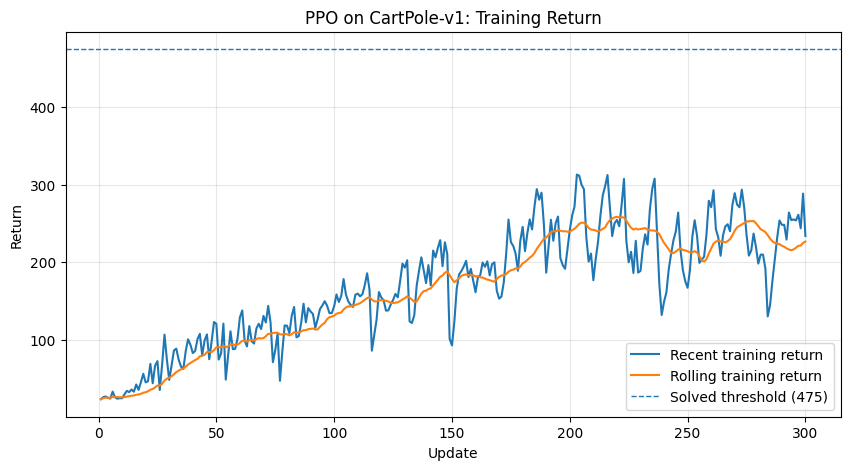

Saved plot to: ..\Results\ppo\ppo_training_return.png


In [13]:
plt.figure(figsize=(10, 5))
plt.plot(
    ppo_history_plot["update"],
    ppo_history_plot["mean_training_return_last_20"],
    label="Recent training return",
)
plt.plot(
    ppo_history_plot["update"],
    ppo_history_plot["rolling_training_return"],
    label="Rolling training return",
)

plt.axhline(
    y=ppo_config.solved_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Solved threshold ({ppo_config.solved_threshold:.0f})",
)

plt.xlabel("Update")
plt.ylabel("Return")
plt.title("PPO on CartPole-v1: Training Return")
plt.legend()
plt.grid(True, alpha=0.3)

ppo_training_plot_path = RESULTS_DIR / "ppo_training_return.png"
plt.savefig(ppo_training_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {ppo_training_plot_path}")

The training return shows the performance of episodes generated by the stochastic PPO policy during data collection. It is expected to be noisier than greedy evaluation because PPO samples actions from the policy distribution during rollout.

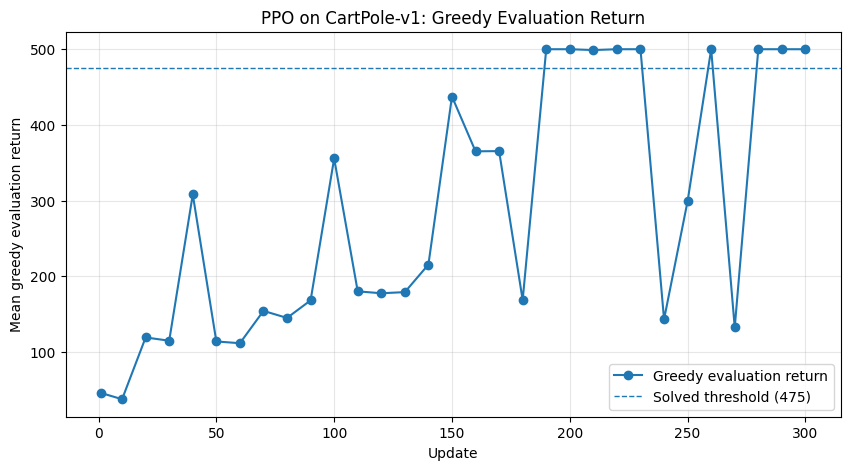

Saved plot to: ..\Results\ppo\ppo_greedy_evaluation_return.png


In [14]:
eval_points = ppo_history_plot.dropna(subset=["eval_mean_return"])

plt.figure(figsize=(10, 5))
plt.plot(
    eval_points["update"],
    eval_points["eval_mean_return"],
    marker="o",
    label="Greedy evaluation return",
)

plt.axhline(
    y=ppo_config.solved_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Solved threshold ({ppo_config.solved_threshold:.0f})",
)

plt.xlabel("Update")
plt.ylabel("Mean greedy evaluation return")
plt.title("PPO on CartPole-v1: Greedy Evaluation Return")
plt.legend()
plt.grid(True, alpha=0.3)

ppo_eval_plot_path = RESULTS_DIR / "ppo_greedy_evaluation_return.png"
plt.savefig(ppo_eval_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {ppo_eval_plot_path}")

The greedy evaluation return measures the deterministic policy obtained by selecting the highest-probability action. PPO reaches the maximum CartPole return of 500, showing that the learned policy can solve the environment.

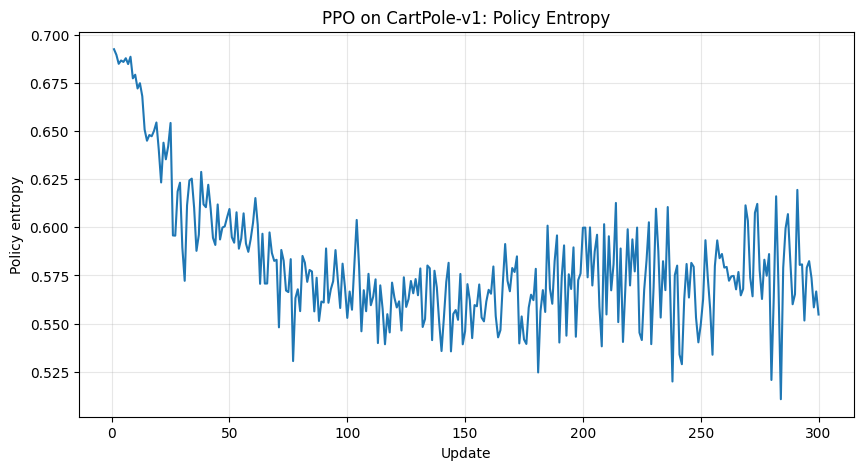

Saved plot to: ..\Results\ppo\ppo_policy_entropy.png


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(ppo_history_plot["update"], ppo_history_plot["entropy"])
plt.xlabel("Update")
plt.ylabel("Policy entropy")
plt.title("PPO on CartPole-v1: Policy Entropy")
plt.grid(True, alpha=0.3)

ppo_entropy_plot_path = RESULTS_DIR / "ppo_policy_entropy.png"
plt.savefig(ppo_entropy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {ppo_entropy_plot_path}")

Entropy measures how uncertain the policy is. Higher entropy means the policy is more exploratory, while lower entropy means the policy has become more confident in particular actions. In PPO, the entropy bonus encourages exploration during training.

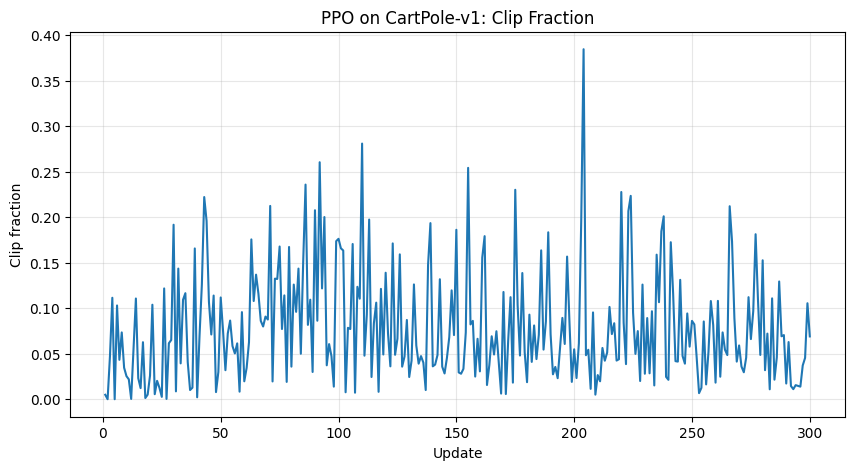

Saved plot to: ..\Results\ppo\ppo_clip_fraction.png


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(ppo_history_plot["update"], ppo_history_plot["clip_fraction"])
plt.xlabel("Update")
plt.ylabel("Clip fraction")
plt.title("PPO on CartPole-v1: Clip Fraction")
plt.grid(True, alpha=0.3)

ppo_clip_plot_path = RESULTS_DIR / "ppo_clip_fraction.png"
plt.savefig(ppo_clip_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {ppo_clip_plot_path}")

The clip fraction shows the proportion of mini-batch samples affected by PPO’s clipping rule. A non-zero clip fraction indicates that the clipped objective is actively limiting some policy updates, which is the stabilising mechanism PPO is designed around.

## 10.1 PPO Performance Summary

I summarise PPO performance using best evaluation return, final evaluation return, final recent training return, and the first update where the greedy evaluation reaches the solved threshold.

In [17]:
ppo_eval_points = ppo_history.dropna(subset=["eval_mean_return"])

best_eval_idx = ppo_eval_points["eval_mean_return"].idxmax()
best_eval_row = ppo_eval_points.loc[best_eval_idx]
final_row = ppo_history.iloc[-1]

solved_eval_rows = ppo_eval_points[
    ppo_eval_points["eval_mean_return"] >= ppo_config.solved_threshold
]

first_solved_update = (
    int(solved_eval_rows["update"].iloc[0])
    if len(solved_eval_rows) > 0
    else np.nan
)

ppo_summary = {
    "best_eval_mean_return": best_eval_row["eval_mean_return"],
    "best_eval_update": int(best_eval_row["update"]),
    "final_eval_mean_return": final_row["eval_mean_return"],
    "final_training_return_last_20": final_row["mean_training_return_last_20"],
    "first_solved_update_by_eval": first_solved_update,
    "final_entropy": final_row["entropy"],
    "final_clip_fraction": final_row["clip_fraction"],
    "total_environment_steps": int(final_row["global_step"]),
}

ppo_summary_df = pd.DataFrame([ppo_summary]).round(3)
ppo_summary_df

,best_eval_mean_return,best_eval_update,final_eval_mean_return,final_training_return_last_20,first_solved_update_by_eval,final_entropy,final_clip_fraction,total_environment_steps
0,500.0,190,500.0,234.0,190,0.555,0.069,307200


The summary table shows that PPO reaches the maximum greedy evaluation return of 500. The final evaluation return is also 500, meaning the final policy remains successful rather than only achieving a temporary peak.

In [18]:
ppo_summary_path = RESULTS_DIR / "ppo_summary.csv"
ppo_history_path = RESULTS_DIR / "ppo_training_history.csv"

ppo_summary_df.to_csv(ppo_summary_path, index=False)
ppo_history_plot.to_csv(ppo_history_path, index=False)

print(f"Saved PPO summary to: {ppo_summary_path}")
print(f"Saved PPO history to: {ppo_history_path}")

Saved PPO summary to: ..\Results\ppo\ppo_summary.csv
Saved PPO history to: ..\Results\ppo\ppo_training_history.csv


I save the PPO summary and training history so that the numerical results can be reused in the written report and presentation.

## 10.2 Quantitative Analysis

The PPO agent successfully learns a high-performing policy for `CartPole-v1`. The best greedy evaluation return is 500.0, which is the maximum possible return in the environment. The first update where PPO reaches the solved threshold is update 190, and the final evaluation return at update 300 is also 500.0. This shows that PPO does not only reach a temporary peak; the final trained policy remains successful.

The training return is lower and noisier than the greedy evaluation return. This is expected because PPO collects rollout data by sampling from its stochastic policy, while greedy evaluation selects the highest-probability action deterministically. Therefore, training return reflects exploratory on-policy behaviour, whereas greedy evaluation better represents the final deterministic policy quality.

The entropy curve decreases from its initial high value and then fluctuates around a lower range. This indicates that the policy becomes more confident over training while still retaining some stochasticity due to the entropy bonus. The clip fraction remains mostly non-zero, showing that PPO’s clipping mechanism is actively limiting some policy updates. This supports the intended role of PPO: allowing policy improvement while reducing the risk of overly large destructive updates.

## 10.3 Qualitative Analysis

PPO behaves differently from DQN because it directly optimises a parameterised policy instead of learning Q-values and selecting actions through a value function. In CartPole, this means PPO learns action probabilities for pushing the cart left or right given the pole state. The critic supports this process by estimating state values, which reduces variance in the policy-gradient update.

Compared with the DQN results, PPO produced a cleaner final policy. The DQN variants achieved high peak performance, especially Dueling DQN and Double + Dueling DQN, but their later performance was unstable. PPO also showed noisy training returns, but the final greedy evaluation remained at the maximum return of 500.0. This suggests that PPO was more stable in this experiment.

The difference is partly explained by the PPO clipped objective. DQN uses bootstrapped Q-learning targets, which can become unstable because the target values depend on changing neural-network estimates. PPO instead constrains policy updates using the probability ratio between the old and new policies. This makes each update more conservative and helps prevent the policy from changing too aggressively after a good behaviour has been learned.

## 10.4 Limitations and Further Improvements

Although PPO performs well in this experiment, there are still limitations. I only train with one random seed, so the result does not measure variation across different initialisations. A more rigorous experiment would train several PPO agents with different seeds and report the mean and standard deviation of final performance.

The training return also remains below the greedy evaluation return because rollout data is sampled from a stochastic policy. This is not necessarily a failure, but it shows that the training curve should not be interpreted alone. Greedy evaluation is needed to judge the policy that would actually be used after training.

Further improvements could include multiple random seeds, learning-rate scheduling, longer training, early stopping based on evaluation return, and checkpointing of the best evaluation model. These changes would make the results more robust and easier to reproduce.

## 10.5 Comparison with DQN

The DQN and PPO experiments both solve the same continuous-observation control problem, but they do so using different reinforcement learning principles. DQN is value-based: it learns Q-values and derives a policy by selecting the action with the highest estimated value. PPO is policy-based with an actor-critic structure: it directly learns a stochastic policy while using a critic to estimate state values.

In my experiments, the strongest DQN variants reached high peak performance, but the final DQN policies were unstable. PPO reached the maximum greedy evaluation return of 500.0 and also finished training with a final evaluation return of 500.0. This makes PPO the more stable final method in this specific experiment.

This comparison shows why algorithm choice matters in deep reinforcement learning. DQN can be effective for discrete-action tasks, especially with improvements such as Double DQN and Dueling DQN, but it can be sensitive to bootstrapping and function-approximation instability. PPO’s clipped policy update provides a more conservative optimisation process, which produced more reliable final performance on this CartPole task.

In [19]:
ppo_weights_path = RESULTS_DIR / "ppo_actor_critic_weights.npz"

ppo_state_dict_numpy = {
    key: value.detach().cpu().numpy()
    for key, value in ppo_model.state_dict().items()
}

np.savez(ppo_weights_path, **ppo_state_dict_numpy)

print(f"Saved PPO actor-critic weights to: {ppo_weights_path}")

Saved PPO actor-critic weights to: ..\Results\ppo\ppo_actor_critic_weights.npz


The trained PPO actor-critic weights are saved in NumPy format for reproducibility. The notebook also saves the PPO summary and training history, so the results can be inspected without rerunning the full training process.